# A modulation over many unit cells

A spin density wave in chromium repeats every 21 unit cells. A charged impurity in
silicon is screened over about 20. A skyrmion is hundreds across. Each of them is a
slow envelope on a crystal that is still atomically periodic, and a supercell pays
the same price for the envelope as it does for the atoms, which is why that length
scale is an awkward one to reach.

This notebook applies a potential that varies over eight unit cells of silicon and
watches the electrons screen it. The trick is that the eight-cell problem is solved
in the basis of the ordinary two-atom cell's own Kohn-Sham states, computed once at
the k-points that fold onto the long cell. The self-consistency then runs on the
envelope alone.

A cosine of amplitude 0.02 Ry applied over eight unit cells comes out reduced to a
tenth of itself. The dielectric screening at that wavelength is **10.6**, against
silicon's measured 11.9 in the long-wavelength limit, and it falls to **6.8** when
the modulation is squeezed into four cells instead. The last section does the same
thing with a magnetic field and gets a spin density wave eight cells long, which is
the shape of the problem the method was built for.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from defumat import Calculator

calc = Calculator.from_file('../tests/data/qe/si-ultracell.in',
                            pseudo_dir='../tests/data/pseudo')
applied = lambda x: 0.02 * np.cos(2 * np.pi * x[..., 0] / 8)
ulr = calc.get_ultracell(supercell=(8, 1, 1), kgrid=(1, 2, 2),
                         nbnd=32, external=applied)
print(f'eight unit cells, {ulr.iterations} iterations')
print(f'induced density   {np.abs(ulr.modulation).max():.3e} e/bohr^3')

[defumat] an ultracell calculation: no ground state cached, running the SCF first (conv_thr = 1e-10). Call get_scf() to do this explicitly.


eight unit cells, 9 iterations
induced density   7.655e-05 e/bohr^3


## What is being solved

The long cell is $N = 8$ copies of the unit cell. Its reciprocal lattice vectors
that lie inside the ordinary Brillouin zone are $N$ wavevectors $\mathbf Q$, and
anything allowed to vary slowly is written as

$$\rho(\mathbf r) = \sum_{\mathbf Q} \rho_{\mathbf Q}(\mathbf r)\,
   e^{i\mathbf Q\cdot\mathbf r},$$

with each $\rho_{\mathbf Q}$ periodic on the unit cell. The states of the long cell
are expanded in the unit cell's own states at the $N$ k-points that fold onto each
long-cell k-point,

$$|\Psi\rangle = \sum_{\mathbf Q, n} c_{\mathbf Q n}\,
   |\psi_{\mathbf k + \mathbf Q, n}\rangle ,$$

so what is diagonalised each iteration is a small dense matrix rather than a
plane-wave Hamiltonian. Those unit-cell states are computed once, before the loop,
and never again.

As the number of bands per folded k-point grows, that basis becomes the long cell's
own complete plane-wave basis, so this is a variational truncation of the real
supercell problem and nothing else. The number of bands is the one convergence
parameter, and the default for an insulator, which is the occupied bands and nothing
above them, leaves the envelope nothing to be built from.

In [2]:
# everything below is one plane-averaged profile along the modulated axis
box = ulr.ultracell.grid
x = np.arange(box[0]) * 8.0 / box[0]        # position in unit cells

profile = lambda f: np.asarray(f).reshape(box).mean(axis=(1, 2))
v_total = profile(ulr.delta_v[0])
rho_ind = profile(ulr.modulation[0])
v_ext = 0.02 * np.cos(2 * np.pi * x / 8)

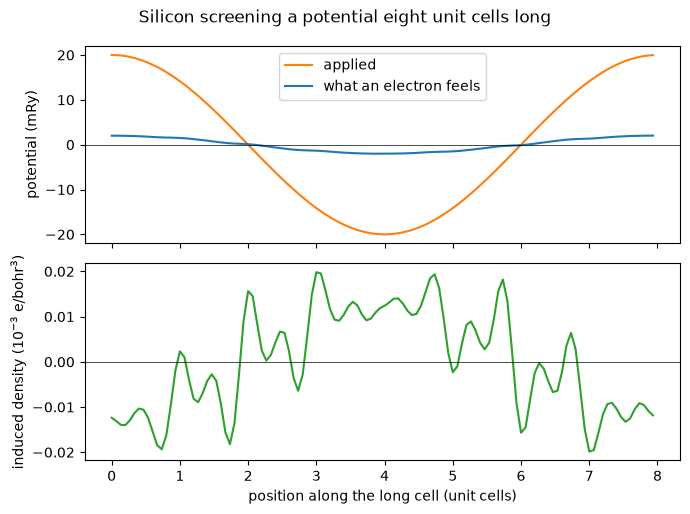

In [3]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(7, 5.2), sharex=True)
top.plot(x, v_ext * 1000, label='applied', color='C1')
top.plot(x, v_total * 1000, label='what an electron feels', color='C0')
top.set_ylabel('potential (mRy)'); top.legend(); top.axhline(0, lw=0.5, c='k')
bottom.plot(x, rho_ind * 1000, color='C2')
bottom.axhline(0, lw=0.5, c='k')
bottom.set_xlabel('position along the long cell (unit cells)')
bottom.set_ylabel(r'induced density (10$^{-3}$ e/bohr$^3$)')
fig.suptitle('Silicon screening a potential eight unit cells long')
fig.tight_layout()

## The screening

The electrons pile up where the applied potential is low, and the Hartree potential
of that pile-up cancels most of what was applied. The ratio of the two is the
dielectric function at the applied wavevector,

$$\epsilon(\mathbf Q) = \frac{V_{\rm ext}(\mathbf Q)}
   {V_{\rm ext}(\mathbf Q) + V_{\rm H}[\delta\rho](\mathbf Q)} .$$

Silicon's static dielectric constant is 11.9 by experiment, and that is the
$\mathbf Q \to 0$ limit. A finite wavelength screens less well, so the number should
fall as the modulation is squeezed into fewer cells, and it does. The cutoff here is a
tutorial one rather than a converged one, so read these as the right size and the right
trend rather than as converged values.

In [4]:
def screening(result):
    # epsilon(Q) from the induced charge's own Hartree potential
    shape = result.ultracell.grid
    induced = np.fft.fftn(np.asarray(result.modulation[0])) / np.prod(shape)
    q2 = result.ultracell.g2(calc.system.cell).reshape(shape)[1, 0, 0]
    hartree = 8 * np.pi * induced[1, 0, 0].real / q2     # Rydberg atomic units
    return np.sqrt(q2), 0.01, hartree, 0.01 / (0.01 + hartree)

short = calc.get_ultracell(supercell=(4, 1, 1), kgrid=(1, 2, 2), nbnd=32,
                           external=lambda x: 0.02 * np.cos(2 * np.pi * x[..., 0] / 4))
print(f"{'cells':>6}{'|Q| (1/bohr)':>15}{'applied':>12}{'induced V_H':>14}{'epsilon':>10}")
for cells, run in ((4, short), (8, ulr)):
    q, applied, hartree, eps = screening(run)
    print(f'{cells:>6}{q:>15.4f}{applied*1000:>10.2f} mRy{hartree*1000:>11.2f} mRy{eps:>10.2f}')

 cells   |Q| (1/bohr)     applied   induced V_H   epsilon
     4         0.2667     10.00 mRy      -8.53 mRy      6.79
     8         0.1334     10.00 mRy      -9.06 mRy     10.61


## A spin density wave

The same machinery with two spin channels answers the question the method was
built for. A magnetic field that varies over eight unit cells drives a
magnetization that varies with it, and the moment of each cell traces out the
wave.

The cell below has no moment of its own. Nothing in a collinear calculation
breaks spin symmetry by itself, so what the field induces here is the spin
response of a nonmagnetic crystal rather than the rearrangement of moments that
were already there. The two channels share one Fermi level, which is what lets
an electron cross from the minority channel in one cell to the majority channel
in the next. That crossing is what a spin density wave is made of.


In [5]:
magnetic = Calculator.from_file('../tests/data/qe/si-ultracell-mag.in',
                                pseudo_dir='../tests/data/pseudo')
field = lambda x: 0.02 * np.cos(2 * np.pi * x[..., 0] / 8)
wave = magnetic.get_ultracell(supercell=(8, 1, 1), kgrid=(1, 2, 2), nbnd=32,
                              magnetic_field=field, david=2)

moments = wave.cell_moments()
print(f'eight unit cells, {wave.iterations} iterations')
print(f'largest cell moment   {np.abs(moments).max():.4f} mu_B')
print(f'net moment            {moments.sum():+.2e} mu_B')


[defumat] an ultracell calculation: no ground state cached, running the SCF first (conv_thr = 1e-10). Call get_scf() to do this explicitly.


/u/40/ladovj1/data/Documents/programs/claude/defumat/defumat/ultracell/driver.py:494: UserWarning: the fixed-density solve did not converge at 18 of 64 k-points: up to 2 of 32 bands are unsettled and the worst k-point took 100 Davidson steps, at ethr = 1.2e-08 (from conv_thr = 1.0e-06). There is no later iteration to fix this -- the density is fixed -- so these wavefunctions are what every quantity built on them will use. Loosen conv_thr (ethr is 0.1 x conv_thr / nelec, QE's setup.f90 rule) before raising the iteration budget: a threshold the solve cannot reach costs the whole budget at every k-point and is where an overlap loses positivity
  calculation, folded_system, eigenvalues, wavefunctions = fixed_density_states(


eight unit cells, 8 iterations
largest cell moment   0.1223 mu_B
net moment            +3.26e-09 mu_B


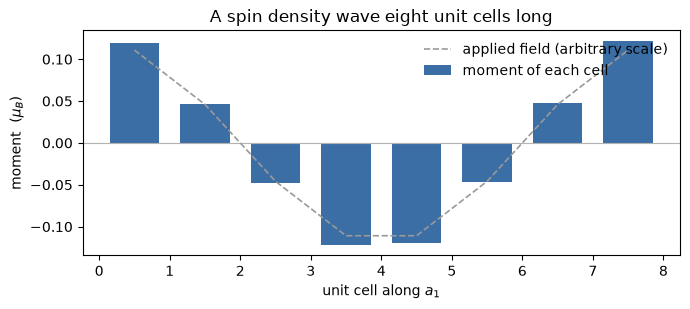

In [6]:
cells = np.arange(len(moments))
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(cells + 0.5, 0.02 * np.cos(2 * np.pi * (cells + 0.5) / 8) * 6,
        color='0.6', lw=1.2, ls='--', label='applied field (arbitrary scale)')
ax.bar(cells + 0.5, moments, width=0.7, color='#3b6ea5', label='moment of each cell')
ax.set_xlabel('unit cell along $a_1$')
ax.set_ylabel(r'moment  ($\mu_B$)')
ax.set_title('A spin density wave eight unit cells long')
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()


The moment follows the field cell by cell and sums to zero over the eight of
them, because the field does too. What is left over is the response itself: the
ratio of the two is the spin susceptibility at that wavelength, and it is the
magnetic counterpart of the screening measured above.

The charge barely moves. A collinear crystal is unchanged by flipping every spin
at the same time as the sign of the field, so the charge cannot respond at first
order in the field and the magnetization must, which is a useful check that the
two channels are being kept apart properly.


## What it cannot do

The atoms do not move, and the unit cell's band structure is frozen: this computes
what a slow modulation does to a fixed crystal, not what a different crystal does.
A modulation strong enough to change the local chemistry has to be absorbed by the
empty states, which is the reason the band count is worth converging rather than
guessing.

There is also no total energy here. The occupied eigenvalues are summed and reported,
and that is all either this code or Elk offers for a calculation of this kind, so the
energy gain of a modulated state over a uniform one is not yet a quantity to read off.

The checks live in `tests/regression/test_ultracell.py`, where a two-cell ultracell is
compared against a real four-atom supercell run in full, and the disagreement in the
induced density is shown to fall from 43 per cent at eight bands to 0.2 per cent at
eighty. The magnetic side is checked the same way, against a supercell and against an
ordinary calculation carrying the same uniform field. The index bookkeeping the long cell needs is checked separately in
`tests/unit/test_ultracell_grid.py`.